In [ ]:
# 실습 준비 — 04주차 추측통계의 기본
# 이 셀을 먼저 한 번 실행하세요. 데이터가 없으면 아래 셀들이 전부 실패합니다.
import os, pathlib, urllib.request

BASE = "https://raw.githubusercontent.com/aprilslab/statistics-lab/main/data/"
FILES = ["ch4_scores400.csv"]

pathlib.Path("data").mkdir(exist_ok=True)
for name in FILES:
    for dest in (pathlib.Path(name), pathlib.Path("data") / name):
        if not dest.exists():
            urllib.request.urlretrieve(BASE + name, dest)

# '../data/x.csv' 로 읽는 노트북 대응 — 상위 폴더에도 같은 data/ 를 걸어둔다.
# 절대경로(/data)로 박으면 cwd 가 /content 가 아닐 때 깨지므로 상대경로로 건다.
try:
    parent = pathlib.Path("..") / "data"
    if not parent.exists():
        os.symlink(pathlib.Path("data").resolve(), parent)
except OSError:
    pass

print("준비 완료:", ", ".join(FILES) if FILES else "(내려받을 데이터 없음)")


# 추측통계의 기본 (부제: 일부로 전체를 추측해보자!)

In [ ]:
# 우리는 colab에 파일을 올려놓고 데이터를 읽어 올 것이기 때문에 google drive를 먼저 연결해줍니다.
# 좌측의 폴더 버튼을 누르세요.
# 상단의 구글 마크가 있는 폴더 버튼을 눌러서 마운트 해주세요.
# 마운트 버튼을 누르면 코랩을 연결하는 코드 셀이 생성됩니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 데이터에 편하게 접근하기 위해 working directory를 data 폴더로 지정해줍니다.
# 본인이 코드를 받은 폴더 내부에 있는 data 폴더 우클릭하여 '경로복사'를 수행합니다.
# 복사한 경로를 work_dir에 붙여넣고 실행합니다.
import os
# work_dir = '{나의 data 폴더 경로}'
work_dir = '/content/drive/MyDrive/데이터통계분석/source/data'
os.chdir(work_dir)

In [3]:
# 현재 나의 위치를 확인해봅니다.
!pwd

/content/drive/MyDrive/데이터통계분석/source/data


In [4]:
# 현재 폴더에 있는 파일 목록을 출력해봅니다.
!ls

ch10_access.csv   ch11_potato.csv	 ch12_scores_reg.csv  ch3_anscombe.npy
ch10_enquete.csv  ch11_training_ind.csv  ch1_sport_test.csv   ch4_scores400.csv
ch11_ad.csv	  ch11_training_rel.csv  ch2_scores_em.csv    Untitled.ipynb


<br><br>
## 모집단과 표본

2장과 3장에서 다룬 통계를 기술 통계라고합니다. <br>
기술 통계에서는 평균이나, 분산 등의 지표로 데이터를 요약하거나 시각화함으로써 데이터를 직관적으로 이해할 수 있게 하였습니다.<br>

이번장에서 배울것은 추측통계입니다.<br>
추측 통계는 일부 데이터로부터 전체의 통계적 성질을 추측하는 방식입니다.<br>

교재 p.92 [그림 4-1] 모집단과 표본 그림 참고<br>

추측 통계에서는 관측 대상 전체의 통계적 성질을 그 관측 대상의 일부분만 사용하여 추측합니다.
- **모집단(population)**: 추측하고 싶은 관측 대상 **전체**
- **표본(sample)**: 추측에 사용되는 관측 대상의 **일부분**
- **표본추출(sampling)**: 모집단에서 표본을 골라내는 일
- **표본크기 (또는 샘플사이즈)**: 골라낸 표본의 수
- **표본통계량**: 표본을 바탕으로 계산한 평균이나 분산, 상관계수 등.
- **모수**: 모집단의 평균이나 분산, 상관계수 등.

표본의 평균을 표본 평균, 모수의 평균을 모평균이라 하기도 합니다.<br>
**표본평균**은 모평균의 '**추정량(estimator)**'이라 합니다.<br>
표본의 데이터를 이용하여 **계산한 결과**를 '**추정값(estimate)**'이라 합니다.<br>

예) A학생이 모평균의 추정량으로 표본 평균을 선택하여, 추정값 70.4점을 계산했습니다.

<br>

### 표본의 추출방법

In [5]:
# 라이브러리와 데이터를 준비합니다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)
%precision 3
%matplotlib inline

In [6]:
# 전교생의 데이터는 ch4_scores400.csv에 있습니다.
df = pd.read_csv('ch4_scores400.csv')
scores = np.array(df['score'])

In [7]:
# 10개의 scores 데이터만 출력해봅시다
scores[:10]

array([76, 55, 80, 80, 74, 61, 81, 76, 23, 80])

In [10]:
# - 무작위추출(random sampling): 임의로 표본을 추출하는 방법
# 편향없는 표본 추출을 위함입니다.
# 셀을 실행 할 때 마다 결과가 달라집니다.
# 동일한 숫자가 여러번 추출되는 경우가 있습니다. >> '복원추출(sampling with replacement)'

# 셀을 여러번 실행해봅시다. (ctrl + Enter) 연타!!

np.random.choice([1, 2, 3], 3)

array([1, 1, 1])

In [24]:
# 동일한 숫자가 여러번 추출안되게, 즉, '비복원추출(sampling without replacement)' 하려면?
# np.random.choice 인수 replace를 False로 합니다.

# 셀을 여러번 실행해봅시다. (ctrl + Enter) 연타!!

np.random.choice([1, 2, 3], 3, replace=False)

array([1, 3, 2])

In [25]:
# 무작위 추출을 원했지만, 성능의 비교 테스트 등의 이유로 완전한 난수가 되면 곤란한 경우가 있습니다.
# 이런 경우 난수 시드(seed)를 도입합니다.
# 난수 시드를 정해두면 매번 동일한 난수를 얻을 수 있습니다.

# 셀을 여러번 실행해봅시다. (ctrl + Enter) 연타!!

np.random.seed(0)
np.random.choice([1, 2, 3], 3)

array([1, 2, 1])

In [27]:
# scores에서 표본 크기가 20인 표본을 추출해봅시다
np.random.choice(scores, 20)

array([52, 61, 77, 91, 80, 56, 69, 67, 90, 56, 75, 79, 60, 79, 68, 81, 56,
       55, 79, 91])

In [28]:
# 난수시드를 설정하고 표본 크기가 20인 표본을 추출해봅시다
np.random.seed(0)
sample = np.random.choice(scores, 20)

In [30]:
# 해당 표본의 표본평균을 구해봅시다.
np.mean(sample), sample.mean()

(np.float64(70.4), np.float64(70.4))

In [31]:
# 우리는 전교생의 점수도 갖고 있기 때문에 모평균도 구할 수 있습니다.
# 모평균을 구해봅시다.
scores.mean()

np.float64(69.53)

In [32]:
# 무작위 추출을 통해 표본을 추출하고, 표본 평균을 구하는 작업을 몇번 반복해봅니다.
def sampling():
  sample=np.random.choice(scores, 20)
  print(f"sample: {sample}")
  print(f"mean: {sample.mean()}")

for _ in range(0, 5):
  sampling()

sample: [56 55 79 91 86 79 83 55 85 76 81 57 77 99 61 57 81 73 59 59]
mean: 72.45
sample: [80 50 85 86 85 59 72 58 31 60 56 64 49 88 66 63 63 47 67 45]
mean: 63.7
sample: [31 55 77 61 54 57 72 46 52 76 92 63 63 80 94 70 76 61 80 61]
mean: 66.05
sample: [47 60 65 86 65 74 76 60 85 78 73 70 68 86 58 74 67 67 83 92]
mean: 71.7
sample: [54 73 92 81 87 56 96 57 93 67 90 54 90 75 46 80 63 57 78 94]
mean: 74.15


<br><br>
## 확률 모델 (모형)

모델링을 함으로써 복잡한 현상을 분석할 수 있게 됩니다.
* 모델링: 확률 현상을 모형처럼 취급하여 단순화하는 것. <br>



### 확률의 기본

* **확률변수(random variable)**:  
  - 수학적 정의: 표본공간의 각 원소에 실수 값을 대응시키는 **함수**
    * 예: 동전을 던질 때 앞면이 나오는 횟수를 반환하는 함수 (0,1 값이 나올 수 있음)
  - 직관적 설명
    * 결과를 알아 맞힐 수는 없지만, 취하는 값과 그 값이 나올 확률이 결정되어 있는 것
    * 결과가 정해지지 않은 상태에서 불확실성을 가진 것.
* **시행(trial)**:
  - 확률변수의 결과를 관측하는 것
  - 예: 동전을 던지는 실제 행위
* **실현값(realization)**:
  - 시행에의해 관측되는 값
  - 예: 동전 던지기 시행에서 실제로 얻은 값 >> 1, 1, 0, 1 ..
* **사건(event)**:
  - 시행 결과로 나타날 수 있는 일
  - 예: 주사위 눈이 1 나옴, 주사위 눈이 홀수나옴
* **근원사건(elementary event)**:
  - 더 세부적으로 분해할 수 없는 사건
  - 예: 주사위 눈이 1 나옴
* **확률(probability)**:
  - 0과 1사이의 연속형 값
* **확률함수(probability function)**:
  - 확률변수로 부터 나온 실수를 확률로 대응시키는 함수
    * 이산형확률함수: 확률질량함수(pmf: Probability mass function)
    * 연속형확률함수: 확률밀도함수(pdf: Probability dentity function)
* **확률분포**:
  - 확률함수로부터 생성된 확률들의 패턴
    * 이산형확률분포
      - 베르누이분포
      - 이항분포
      - 기하분포
      - 포아송 분포
    * 연속형확률분포
      - 정규분포
      - 지수분포
      - 카이제곱분포
      - t분포
      - F분포

<br>

주사위 눈이 1이 되는 사건의 확률이 $\frac{1}{6}$이라는 것은 다음과 같이 표현합니다.
<br>

$P(X=1) = \frac{1}{6}$

<br>

주사위 눈이 홀수가 되는 사건의 확률은 다음과 같이 표현합니다.
<br>

$P((X=1)\cup(X=3)\cup(X=5)) = P(X=1) + P(X=3) + P(X=5) = \frac{1}{6}+\frac{1}{6}+\frac{1}{6} = \frac{1}{2}$

<br>


주사위 눈이 1또는 3또는 5는 동시에 일어 날 수 없기(상호배반) 때문에, '눈이 홀수'라는 사건은 각 확률을 더하여 구할 수 있습니다.
* 사건이 '상호배반(mutually exclusive)'이라는 것 >> 각 사건이 동시에 일어날 수 없다.
* '사건이 상호배반이라면, 그 중 적어도 하나 일어나는 사건은 각 사건의 확률의 합과 같다'

<br>

실험한 주사위 결과 (실현값들): [1 3 6 3 3 5 6 6 2 4 6 4 6 6 1 2 1 6 4 6] ...


/tmp/ipython-input-2380452566.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


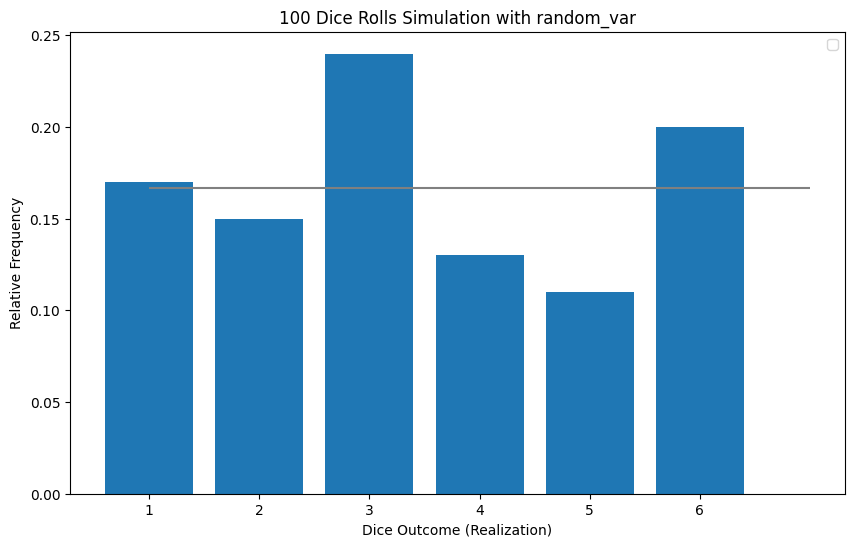

표본평균 (실현값들의 평균): 3.460
모평균 (기댓값): 3.500


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 0. 확률분포 정의
dice = [1, 2, 3, 4, 5, 6]# 주사위 눈금 (확률변수가 가질 수 있는 값)
prob = [1/6] * 6 # 각 눈금이 나올 확률 (균등 분포)

# 1. 확률변수(함수) 정의
# 주사위 눈금 자체를 실현값으로 간주하므로, 입력받은 값을 그대로 반환합니다.
def random_var(outcome: int) -> int:
    """주사위 눈금(outcome)을 확률변수 X의 실현값으로 매핑하는 함수"""
    return outcome

# 2. 실험 (실현값 관측)
# 실제로 주사위를 여러 번 던져서 결과 얻기
trials = 100 # 시행 횟수
# random.choice로 주사위 눈금을 얻고, 이를 random_var 함수에 넣어 실현값을 구합니다.
realizations = random_var(np.random.choice(dice, size=trials, p=prob))

print("실험한 주사위 결과 (실현값들):", realizations[:20], "...") # 처음 20개만 출력

# 3. 실현값들의 분포 확인 (상대도수 히스토그램)
# 실현값들의 분포를 통해 확률변수의 확률분포를 추측해봅니다.
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

# 히스토그램 그리기
ax.hist(realizations, bins=np.arange(0.5, 7.5, 1), density=True, rwidth=0.8)

# 실제 확률분포 (균등 분포)를 가로선으로 표시
# dice_probabilities 리스트 전체를 전달합니다.
ax.hlines(prob, np.arange(1, 7), np.arange(2, 8), colors='gray')

ax.set_xticks(np.arange(1, 7))
ax.set_xlabel('Dice Outcome (Realization)')
ax.set_ylabel('Relative Frequency')
ax.set_title(f'{trials} Dice Rolls Simulation with random_var')
ax.legend()
plt.show()

# 4. 표본평균 계산 (실현값들의 평균)
sample_mean = np.mean(realizations)
print(f"표본평균 (실현값들의 평균): {sample_mean:.3f}")

# 참고: 모평균 (기댓값) 계산
# E(X) = sum(x * P(X=x))
expected_value = sum([x * (1/6) for x in dice])
print(f"모평균 (기댓값): {expected_value:.3f}")

### 확률분포

확률 분포는 확률함수로부터 생성된 확률들의 패턴을 의미합니다.<br>
*'확률변수가 특정 값을 가질 확률이 얼마나 되느냐'*

예)
* 주사위 눈: 확률변수 X
* 주사위의 확률 분포 A
| 눈 (x)        | 1    | 2    | 3    | 4    | 5    | 6    |
|---------------|------|------|------|------|------|------|
| 확률 P(X=x)   | 1/6  | 1/6  | 1/6  | 1/6  | 1/6  | 1/6  |
* '확률변수 X는 확률분포 A를 따른다'

<br>

여기 무게중심이 어긋난 불공정한 주사위가 있다고 해봅시다.<br>
여러분이 이 주사위가 불공정하다는 것을 알지만, 각 눈이 어떤 확률로 나오는지 모른다고 했을 때, <br>
이 불공정한 주사위의 확률분포를 알기 위해 실험을 한다고 해봅시다.<br>

불공정한 주사위는 아래의 확률분포를 따른다고 해봅시다.<br>

| 눈 (x)        | 1    | 2    | 3    | 4    | 5    | 6    |
|---------------|------|------|------|------|------|------|
| 확률 P(X=x)   | 1/21  | 2/21  | 3/21  | 4/21  | 5/21  | 6/21  |

In [34]:
# 확률변수와 그 값이 나오는 확률을 정의합니다.

dice = [1, 2, 3, 4, 5, 6]
prob = [1/21, 2/21, 3/21, 4/21, 5/21, 6/21]

In [35]:
# 확률변수를 시행하기 위해 np.random.choice를 사용해봅시다

np.random.choice(dice, p=prob)

np.int64(4)

In [42]:
# 100번 시행해 봅시다

num_trial = 10000
sample = np.random.choice(dice, num_trial, p=prob)
sample

array([5, 6, 5, ..., 5, 1, 4])

In [43]:
# 시행 결과를 도수분포표로 작성해서 DataFrame으로 예쁘게 출력해봅시다.

freq, _ = np.histogram(sample, bins=6, range=(1, 7))
rel_freq = freq/num_trial


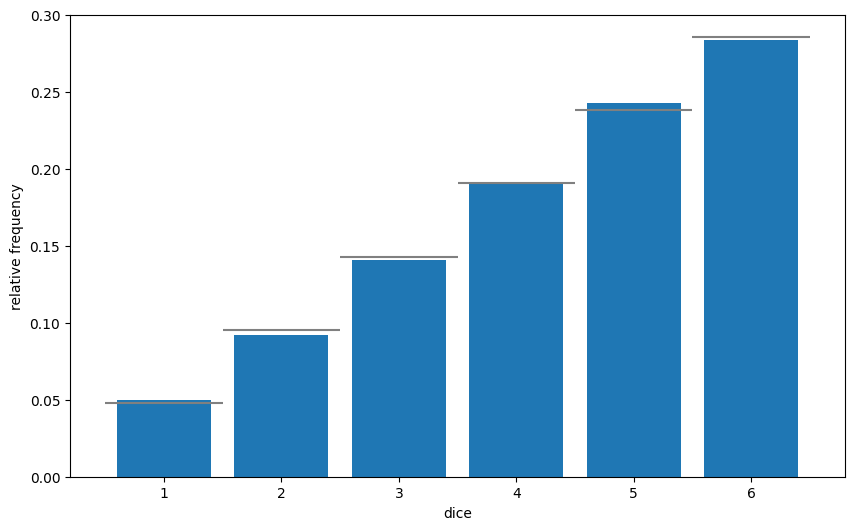

In [44]:
# 실제의 확률분포와 포수분포표를 함께 그려봅니다.

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(sample, bins=6, range=(1, 7), density=True, rwidth=0.8)

# 실제의 확률분포를 가로선으로 표시
ax.hlines(prob, np.arange(1, 7), np.arange(2, 8), colors='gray')

# 막대 그래프의 [1.5, 2.5, ..., 6.5]에 눈금을 표시
ax.set_xticks(np.linspace(1.5, 6.5, 6), labels=np.arange(1,7))
ax.set_xlabel('dice')
ax.set_ylabel('relative frequency')
plt.show()

In [ ]:
# 100번 정도 시행한 것으로는 실제의 확률 분포와는 차이가 있는 것 같습니다.
# 시행횟수를 충분히 늘려서 10000번 시행해봅시다.

# 상대도수가 실제의 확률분포에 가까워진것을 확인할 수 있습니다.

num_trial = 10000
sample = np.random.choice(dice, size=num_trial, p=prob)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(sample, bins=6, range=(1, 7), density=True, rwidth=0.8)
ax.hlines(prob, np.arange(1, 7), np.arange(2, 8), colors='gray')
ax.set_xticks(np.linspace(1.5, 6.5, 6), labels=np.arange(1, 7))
ax.set_xlabel('dice')
ax.set_ylabel('relative frequency')
plt.show()

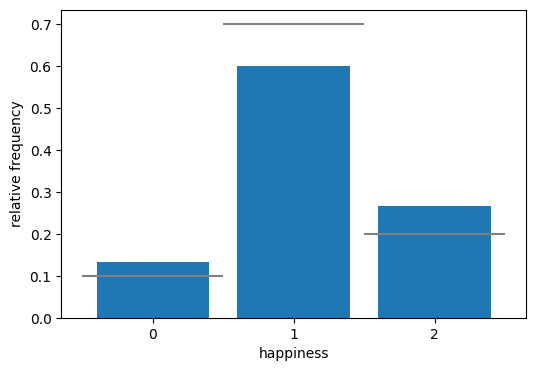

표본평균: 1.1333333333333333
모평균: 1.1


In [50]:
# 고양이의 반응을 시뮬레이션해보자.

import random
import matplotlib.pyplot as plt # matplotlib 추가
import numpy as np # numpy 추가

# 시행 횟수
trials = 15

# 0. 확률분포 정의 (고양이 반응의 가능한 결과 값과 그 확률을 정의합니다.)
reaction = ["물기", "골골송", "뒹굴기"] # 0: 물기, 1: 골골송, 2: 뒹굴기
prob = [0.1, 0.7, 0.2] # 각 반응이 나올 확률

# 1. 확률변수 정의
def random_var(reaction: str):
  if reaction == '물기':
    return 0
  elif reaction == '골골송':
    return 1
  else:
    return 2


# 2. 표본추출 (정의된 확률분포(reaction, prob)에 따라 numpy.random.choice를 사용하여 표본추출을 합니다.)
sample = np.random.choice(reaction, size=trials, p=prob)

# 3. 실험 (실현값 관측)
realizations = [random_var(o) for o in sample]


# 4. 실현값들의 분포 확인 (상대도수/도수 히스토그램)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.hist(realizations, bins=3, range=(-0.5, 2.5), density=True, rwidth=0.8)
ax.hlines(prob,[-0.5,0.5,1.5],[0.5,1.5,2.5], color='gray')
ax.set_xticks([0,1,2], [0,1,2])
ax.set_xlabel('happiness')
ax.set_ylabel('relative frequency')
plt.show()

# 5. 표본평균 계산
print(f"표본평균: {np.mean(realizations)}")

# 6. 모평균 계산
print(f"모평균: {sum([random_var(r) * p for r, p in zip(reaction, prob)])}")

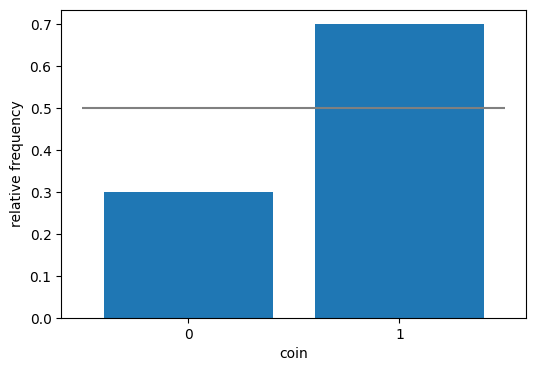

표본평균: 0.7
모평균: [0.5, 0.0]


In [52]:
# 동전던지기 실습

import numpy as np
import matplotlib.pyplot as plt

# 시행횟수
trials = 10

# 0. 확률분포 정의
coin = ["H", "T"] # 동전 던지기의 가능한 결과 (확률변수가 가질 수 있는 값)
prob = [0.5, 0.5] # 각 결과가 나올 확률 (균등 분포)


# 1. 확률변수 정의
def random_var(coin: str):
  return 1 if coin == "H" else 0


# 2. 표본추출 (정의된 확률분포(reaction, prob)에 따라 numpy.random.choice를 사용하여 표본추출을 합니다.)
sample = np.random.choice(coin,size=trials, p=prob)

# 3. 실험 (실현값 관측)
realizations = [random_var(o) for o in sample]


# 4. 실현값들의 분포 확인 (상대도수/도수 히스토그램)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.hist(realizations, bins=2, range=(-0.5, 1.5), density=True, rwidth=0.8)
ax.hlines(prob, [-0.5, 0.5],[0.5,1.5], colors='gray')
ax.set_xticks([0,1])
ax.set_xlabel('coin')
ax.set_ylabel('relative frequency')
plt.show()

# 5. 표본평균 계산
print(f"표본평균: {np.mean(realizations)}")

# 6. 모평균 계산
print(f"모평균: { [random_var(c) * p for c, p in zip(coin, prob)]}")

<br><br>
## 추측통계에서의 확률

앞에서는 주사위를 사용하여 확률 모형에 관해 설명했습니다. <br>
추측통계에서도 마찬가지로 무작위추출(실행)을 확률 모형(수학적기술)으로 기술할 수 있고,<br>
무작위추출로 얻은 표본은 모집단의 확률분포를 따르는 확률변수로 간주할 수 있습니다.<br>

따라서, '추측통계에서 다루는 데이터 = 확률변수의 실현값'이라고 생각할 수 있습니다

<br>

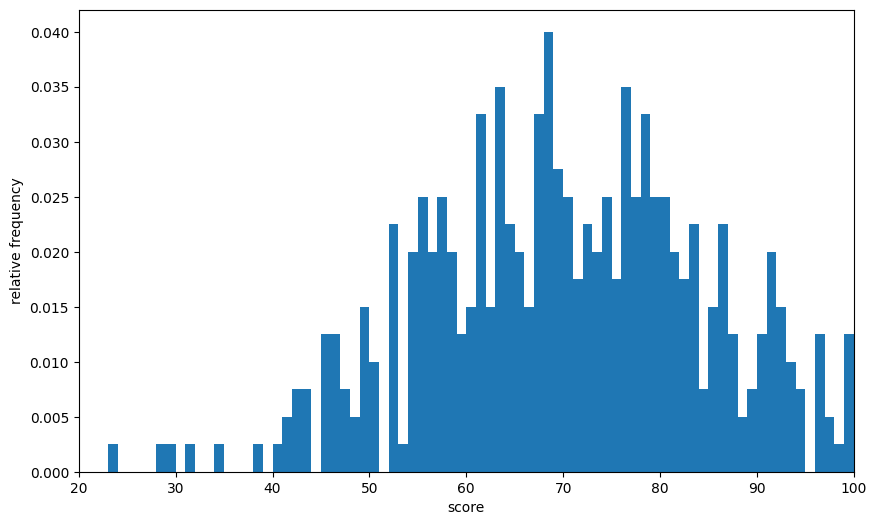

In [53]:
# 전교생의 시험점수가 어떻게 분포되어있는지 알기위해 계급폭을 1점으로 하여 히스토그램을 그려봅시다.
# 히스토그램을 보면 69점을 얻은 학생이 전교생의 4%를 자지하고 있음을 알 수 있습니다 >> 무작위 추출을 수행하면 4%확률로 69점이라는 표본데이터를 얻게 됨.
# 상대도수는 해당 점수를 얻는 확률에 대응합니다. >> 이 히스토그램을 모집단의 확률분포로 간주 할 수 있음.

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(scores, bins=100, range=(0, 100), density=True)
ax.set_xlim(20, 100)
ax.set_ylim(0, 0.042)
ax.set_xlabel('score')
ax.set_ylabel('relative frequency')
plt.show()

In [ ]:
# 무작위추출은 이와 같이 확률분포를 따르는 확률변수의 시행입니다.
# 시행해봅시다.

np.random.choice(scores)

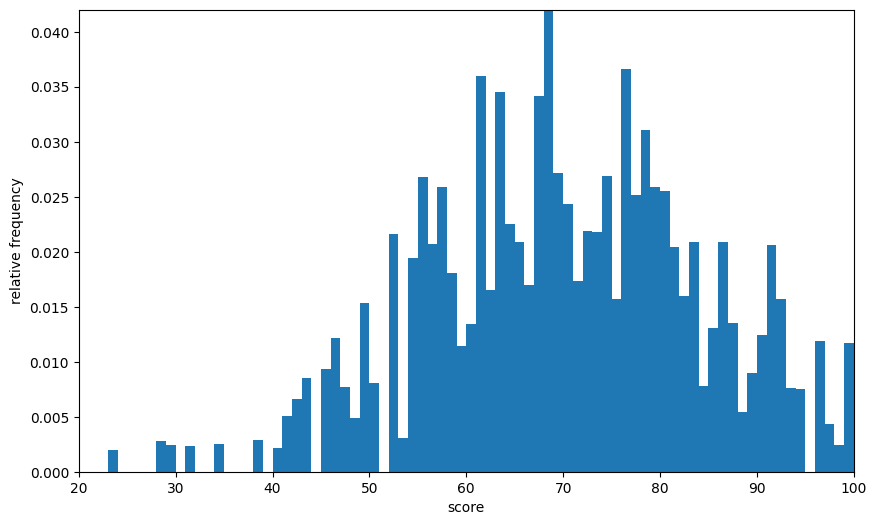

In [54]:
# 표본의 크기가 충분히 커지면, 표본 데이터(실현값)의 상대도수는 실제의 확률분포에 가까워집니다.
# 사이즈가 10000인 표본을 추출하여, 그 결과를 히스토그램으로 그려봅시다.

sample = np.random.choice(scores, 10000)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(sample, bins=100, range=(0, 100), density=True)
ax.set_xlim(20, 100)
ax.set_ylim(0, 0.042)
ax.set_xlabel('score')
ax.set_ylabel('relative frequency')
plt.show()

<br><br>

확률 변수는 다음의 수식과 같이 선형 결합 특징이 있습니다.

$aX + bY (단, a,b\in\mathbb{R})$

<br><br>

따라서, 표본평균은 확률변수의 선형결합으로 아래의 수식의 꼴의 함수가 되어 확률변수로 정의됩니다.
$\frac{1}{n}(X_1+X_2+\dots+X_n)$

<br><br>

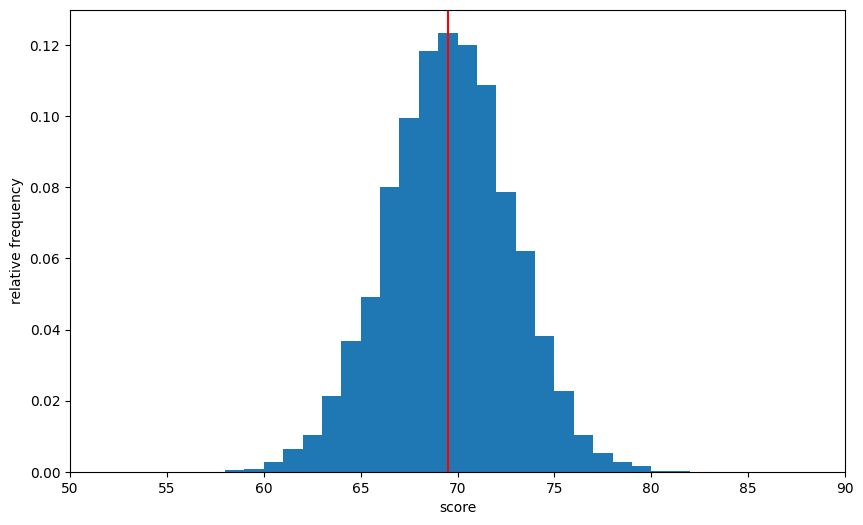

In [55]:
# 무작위추출로 표본크기가 20인 표본을 추출하여 표본평균을 계산하는 작업을 10000번 수행해보고,
# 그 결과를 히스토그램으로 표본평균이 어떻게 분포되는지 살펴봅시다.

sample_means = [np.random.choice(scores, 20).mean()
                for _ in range(10000)]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(sample_means, bins=100, range=(0, 100), density=True)

# 모평균을 세로선으로 표시
ax.vlines(np.mean(scores), 0, 1, 'red')
ax.set_xlim(50, 90)
ax.set_ylim(0, 0.13)
ax.set_xlabel('score')
ax.set_ylabel('relative frequency')
plt.show()

## 이제부터 배우는 것

추측통계
* 추정 (교재 10장)
  * 모수를 추측하는 것.
    * 점추정: 하나의 값을 추정하는 것
    * 구간추정: 구간으로 추정하는 것
* 검정 (교재 11장)
  * 모집단의 통계적 성질에 대해 가설을 세우고, 그 가설이 옳은지 여부를 판다나는 기법

In [ ]:
# colab의 경우 아래의 코드를 수행하여 pdf를 만들어봅시다.
# jupyter notebook의 경우 그냥 pdf로 인쇄를 하여도 예쁘게 잘 출력됩니다.
# 1) 필수 설치
!pip install -q "nbconvert[webpdf]" playwright

# 2) Playwright용 Chromium 설치 (리눅스 의존성도 같이)
!python -m playwright install --with-deps chromium

# 3) (한글 폰트 깨짐 방지, 선택) Noto CJK 설치
!apt-get -y update && apt-get -y install fonts-noto-cjk

# 4) PDF 변환 (실행번호 포함하도록 프롬프트 표시 옵션 유지)
!jupyter nbconvert --to webpdf \
  --TemplateExporter.exclude_input_prompt=False \
  --TemplateExporter.exclude_output_prompt=False \
  ../notebook/chap04.ipynb